In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append('/scratch/users/k21066795/NBT-phenotyping/notebooks')
from utils_vitattn import *

In [2]:
basedir = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS'
save_prefix = f"{basedir}/NBTs_phenotypes03/UNI_MHSA"
print(save_prefix)
os.listdir(save_prefix)

/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_phenotypes03/UNI_MHSA


['cluster_3_BRACS_1810_FEA_27_0_256.png_HE.png',
 'cluster_2_BRACS_1620_PB_1_256_2048.png_attn.png',
 'cluster_1_BRACS_1863_FEA_2_256_0.png_HE.png',
 'cluster_6_BRACS_753_DCIS_30_1024_256.png_attn.png',
 'cluster_0_BRACS_1594_PB_7_1280_768.png_HE.png',
 'cluster_6_BRACS_753_DCIS_30_1024_256.png_HE.png',
 'cluster_5_BRACS_1265_IC_8_2560_768.png_attn.png',
 'cluster_2_BRACS_1620_PB_1_256_2048.png_HE.png',
 'cluster_1_BRACS_1863_FEA_2_256_0.png_attn.png',
 'cluster_4_BRACS_1599_N_2_256_512.png_HE.png',
 'cluster_3_BRACS_1810_FEA_27_0_256.png_attn.png',
 'cluster_4_BRACS_1599_N_2_256_512.png_attn.png',
 'cluster_5_BRACS_1265_IC_8_2560_768.png_HE.png',
 'cluster_0_BRACS_1594_PB_7_1280_768.png_attn.png']

In [3]:
img_dir = "/cephfs/volumes/hpc_data_prj/cb_microbiome/3d70379f-bb3a-4d40-9908-3b0496384f42/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_phenotypes03/patches_examples/UNI_aug_leiden_0.5_clean_imgs"
img_ids = ['cluster_0_BRACS_1594_PB_7_1280_768.png',
           'cluster_4_BRACS_1599_N_2_256_512.png',
           'cluster_1_BRACS_1863_FEA_2_256_0.png',
           'cluster_5_BRACS_1265_IC_8_2560_768.png',
           'cluster_2_BRACS_1620_PB_1_256_2048.png',
           'cluster_6_BRACS_753_DCIS_30_1024_256.png',
           'cluster_3_BRACS_1810_FEA_27_0_256.png']

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

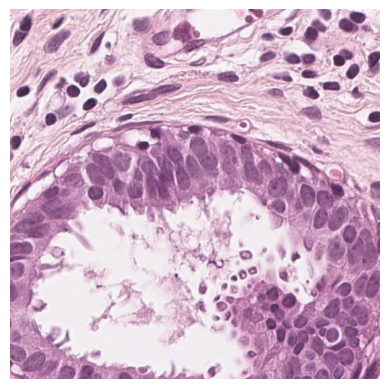

In [7]:
img_id = img_ids[2]
im_pt = f"{img_dir}/{img_id}"
patch = Image.open(im_pt)
patch.save(
    f"{save_prefix}/{img_id}_HE.png",
    dpi=(300, 300)  
)

plt.imshow(patch)
plt.axis('off')

torch.Size([16, 196])
[INFO] Saved plot to /scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_phenotypes03/UNI_MHSA/cluster_1_BRACS_1863_FEA_2_256_0.png_attn.png


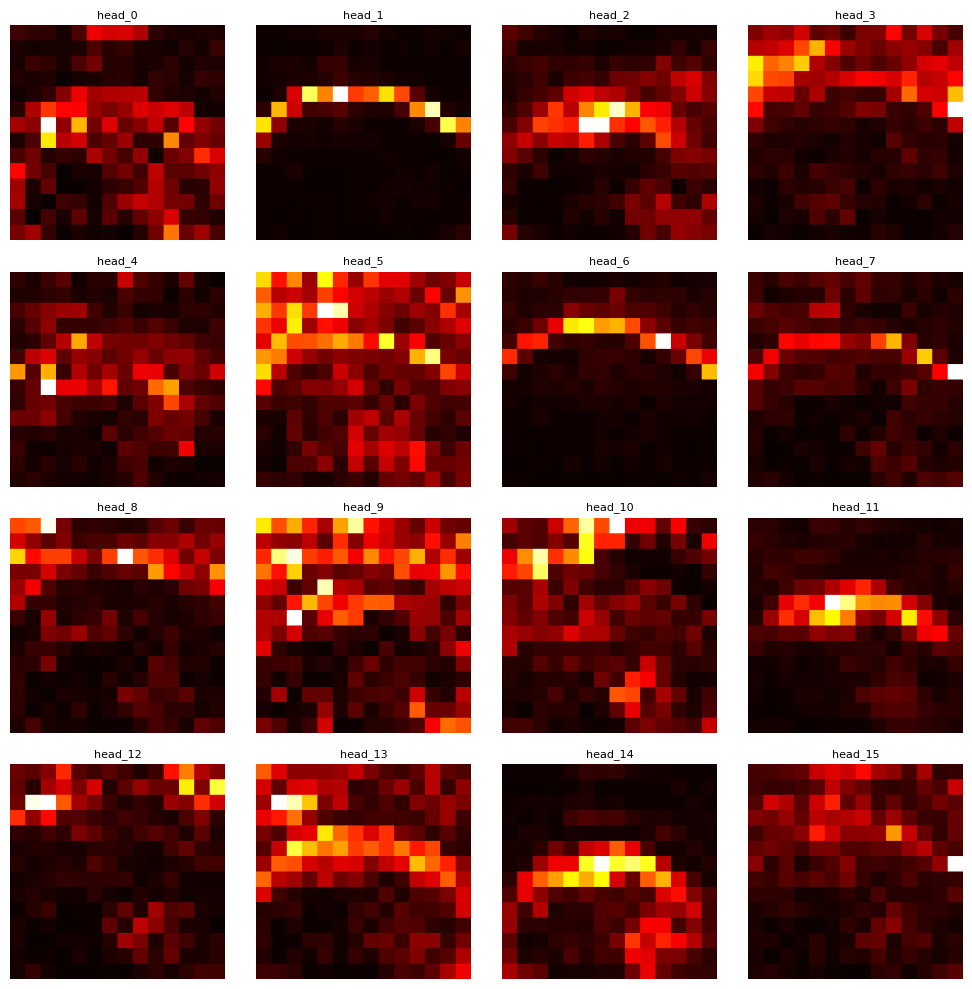

In [8]:
th_attn, attentions = get_attentions_lastlayer(patch, threshold=0.6)
save_pt = f"{save_prefix}/{img_id}_attn.png"
plot_multiple(img_list = attentions, caption_list= [f"head_{i}" for i in range(16)], 
              grid_x=4, grid_y=4, figure_size=(10, 10), cmap = "hot", save_pt=save_pt)